## Assignment 2: Time Series Forecasting

### Ky Cuong Pham , a1906313

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

# Sections in Time Series Forecasting for Appliances
There are two main goals of the any time series forecasting task: describing the pattern of the time series and forecasting. 
Aligning with those goals, we will be forecasting the in-house energy usage using the observed data. The following is the outline of this report 
1. **Paper evaluation** <br>
Knowing about the background of this energy forecasting task is very important. This section will review one of the of the most well-known literature about appliances prediction. We will discuss about the methods they used for the forcasting task and compare with the proposed methods in this report.
2. **Analyse and visualise the Time Series** <br>
In this section, we will try to obtain the most information about the dataset using visualization. This understanding will facilitate suitable data processing and model choosing parts later in the report
3. **Pre-processing the data** <br>
After analysing the data, we will be applying data preprocessing techniques, not only aligning with the previous part, but also with the proposing models. This section is very important for the final result of this report
4. **Model training and selection** <br>
One univariate and one multivariate model will be experimented. The better one will be chosen for the final part 
5. **Testing and analysis of the final model** <br>
After all of the previous steps, we are going to train the most promising model and evaluate its performances. Also, the final model will be compared with the previous report's best model for more logical decision.

***Problem statement*** <br>
We are trying to forecast energy usage (Appliances) using other collected features.


### 1. Paper evaluation

#### Reference
(Candanedo, LM, Feldheim, V & Deramaix, D 2017, 'Data driven prediction models of energy use of appliances in a low-energy house', Energy and buildings, vol. 140, pp. 81-97.)
https://myuni.adelaide.edu.au/courses/105130/files/16388685?wrap=

#### Summary and Critical Evaluation  
That paper proposes a comprehensive method for energy usage prediction, achieving a high score in their chosen metrics. Their method is relatively similar to what we will be doing in this report. In order to review those two works, we will cover these aspects:
1. Data Visualization <br>
The authors used **pair plot** to visualize the relationship between **Appliances** with multiple features. They also introduced some extra features and highlighted the  **Number of Seconds from the Midnight (NMS)**. Additionally, they applied **Boruta's algorithm** to rank feature importance. 
2. Metrics Selection <br>
Root Mean Squared Error (**RMSE**), R-squared (**R<sup>2</sup>**), Mean Absolute Error (**MAE**) and Mean Absolute Percentage Error (**MAPE**) were chosen according to their advantages when being used with their experimented regresion models .
3. Model Selection <br>
Four regression models have been used to train on the dataset:
- **Multiple Linear Regression**  
- **Support Vector Machine (Radial Kernel)**  
- **Random Forest**  
- **Gradient Boosting Machines (GBM)**  
4. Result Evaluation <br>
They provided a detailed result evaluation, discussing feature importance as well as future work directions.
- Best Model Performance (GBM)  
-- **RMSE**: 88.08  
-- **MAPE**: 53.20  
-- **R²**: 0.57  
-- **MAE**: 53.20  


5. Comparing with This work <br>

| Aspect | Paper's Approach | Our Approach |
|--------|----------------|--------------|
| **Final Goal** | Predict energy usage | Predict energy usage |
| **Metrics Selection** | RMSE, MAPE, R², MAE | RMSE, MAPE |
| **Feature Ranking** | Boruta algorithm | Heat map ranking |
| **Models Used** | Regression models (MLR, SVM, RF, GBM) | Time series models (ARIMA, LSTM) |
| **Performance** | RMSE: 88.08, MAPE: 53.20 | Achieved better RMSE and MAPE |

6. Key Takeaways
- Since the final goal is similar, we can inherit their idea about introducing their most contributing feature, **NSM**
- **RMSE and MAPE** will be used as the common ground to compare two works
- According the the authors, their feature ranking method is quite robust for this dataset. However, we achieved better result on our previous work (Assignment 1), so we will stay with our approach which is heat map ranking
- Unlike their study, which focuses on regression models, we will explore 2 time series forecasting models:  **ARIMA (univariate)** and **LSTM (multivariate)**.  
- Our approach **achieved better RMSE and MAPE**, indicating a possible advantage in time series modeling over traditional regression models.






In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import torch
import torch.nn as nn
import torch.optim as optim

from pylab import rcParams
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics

# Ignore warnings
warnings.filterwarnings("ignore")

# Limit rows displayed in notebook
pd.set_option('display.max_rows', 10)  # Limits displayed rows
pd.set_option('display.max_columns', 10)  # Limits displayed columns

### 2. Analyse and visualise the Time Series
This section includes two main parts:
1. Load the data
2. EDA inherited from the previous report and Feature selection
3. Plot the time series for appliances
4. Stationary checking
5. Outlier checking

**Findings**
* The dataset has no missing data, dupplicates or data type inconsistency
* Some features are more important than the others. 

#### 2.1. Load the data

In [3]:
data = pd.read_csv('energydata_complete.csv')
df = data.copy() # create a copy of the data

# Convert date to datetime type, and set it as the index
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

For time series forcasting, indexing by timeframe is essential!

#### 2.2 EDA inherited from the previous report and Feature selection

In [3]:
df.head()

,Appliances,lights,T1,RH_1,T2,...,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,...,2.000000,31.0,2.6,48.320978,48.320978
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,...,2.166667,28.5,2.6,33.339359,33.339359
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,...,2.333333,26.0,2.6,8.168115,8.168115
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,...,2.500000,23.5,2.6,16.197509,16.197509
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,...,2.666667,21.0,2.6,12.559574,12.559574


In [4]:
df.describe()

,Appliances,lights,T1,RH_1,T2,...,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,...,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,96.747206,3.235393,22.030776,39.418672,20.519140,...,3.671039,37.922696,4.055227,25.047636,25.047636
std,97.297111,7.296554,1.469766,3.880367,2.322643,...,2.218070,11.415145,4.220123,14.436670,14.436670
min,10.000000,0.000000,18.600000,27.023333,16.200000,...,0.000000,1.000000,-6.100000,0.005322,0.005322
25%,50.000000,0.000000,21.000000,36.790000,18.890000,...,2.000000,29.000000,0.983000,12.593007,12.593007
50%,60.000000,0.000000,21.823333,38.790000,20.000000,...,3.166667,40.000000,3.600000,25.120708,25.120708
75%,100.000000,0.000000,22.890000,41.400000,21.830000,...,5.000000,40.000000,6.900000,37.454428,37.454428
max,900.000000,50.000000,26.260000,57.496667,29.856667,...,13.000000,66.000000,15.500000,49.992758,49.992758


In [5]:
df.info() # check for missing values and data types

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14941 entries, 2016-02-14 00:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   14941 non-null  int64  
 1   lights       14941 non-null  int64  
 2   T1           14941 non-null  float64
 3   RH_1         14941 non-null  float64
 4   T2           14941 non-null  float64
 5   RH_2         14941 non-null  float64
 6   T3           14941 non-null  float64
 7   RH_3         14941 non-null  float64
 8   T4           14941 non-null  float64
 9   RH_4         14941 non-null  float64
 10  T5           14941 non-null  float64
 11  RH_5         14941 non-null  float64
 12  T6           14941 non-null  float64
 13  RH_6         14941 non-null  float64
 14  T7           14941 non-null  float64
 15  RH_7         14941 non-null  float64
 16  T8           14941 non-null  float64
 17  RH_8         14941 non-null  float64
 18  T9         

In [6]:
df.duplicated().sum() # check for duplicates

0

Refering to the the previous report (Pham 2025), the dataframe does not contain any dupplicates, missing values, the data types is consistent also.  ***Only a few most important data visualization*** will be implemented.


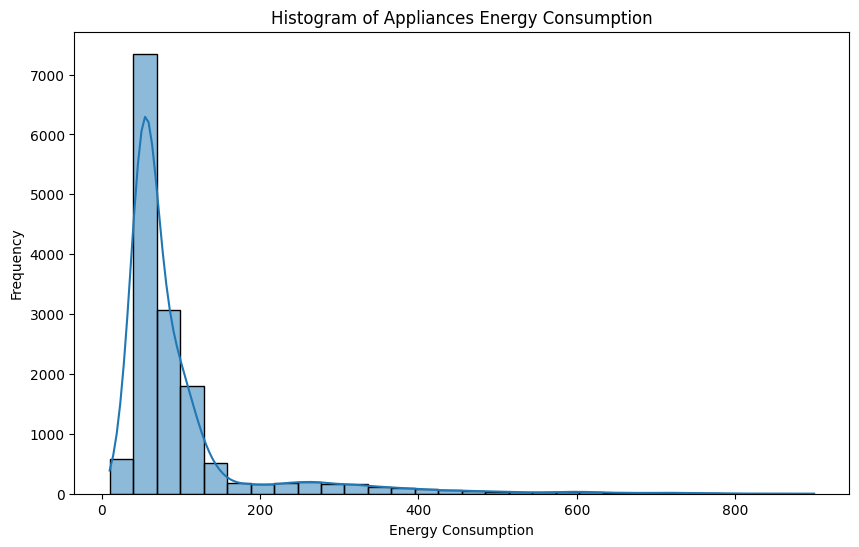

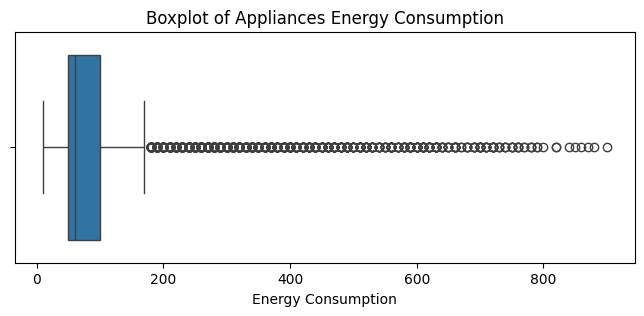

In [6]:
# Plotting histogram of Appliances
plt.figure(figsize=(10, 6))
sns.histplot(data['Appliances'], bins=30, kde=True)
plt.title('Histogram of Appliances Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.show()

#ploting horizontal boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=data['Appliances'])
plt.title('Boxplot of Appliances Energy Consumption')
plt.xlabel('Energy Consumption')
plt.show()



As can be seen from the histogram, most of the values fall between 0 to 100. It is also aligned with the boxplot, where the outliers are presented with a long tail.

***Insight***: Outliers should be removed in the data processing part. Later in section 2.5, we are going to check outliers for other important features(after feature selection at the end of this section) that will be used for multivariate models.

Number of second from midnight (NSM) might be the most valuable feature (Candanedo, Feldheim & Deramaix 2017b). Let's plot it out! 

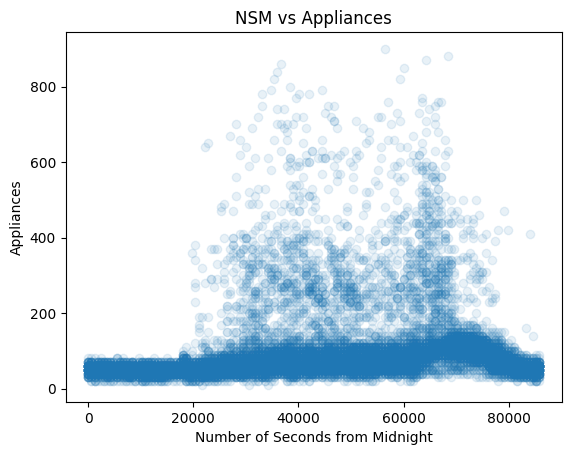

In [7]:
df['NSM'] = pd.to_datetime(df.index) - pd.to_datetime(df.index.date)
df['NSM'] = df['NSM'].dt.total_seconds()

# Plotting NSM vs Appliances
plt.scatter(df['NSM'], df['Appliances'], alpha=0.1)
plt.xlabel('Number of Seconds from Midnight')
plt.ylabel('Appliances')
plt.title('NSM vs Appliances')
plt.show()

The dots tend to fall between 20000 to 70000th second from the midnight. Let's further validate our assumption by ploting the line chart

Text(0, 0.5, 'Appliances')

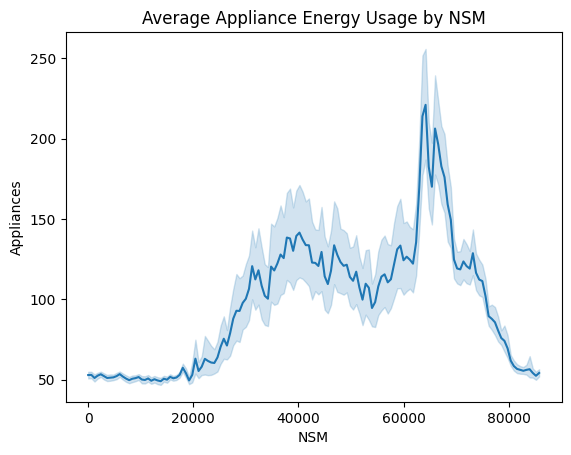

In [ ]:
sns.lineplot(x=df['NSM'], y=df['Appliances'])
plt.title('Average Appliance Energy Usage by NSM')
plt.xlabel('NSM')
plt.ylabel('Appliances')

Between 20000th(5am) to 70000th(8pm), energy usage peaks. It is a common sense that people activities tend to fall between that period. <br>
Now we are going to plot this new feature along with the existings on the correlation matrix.

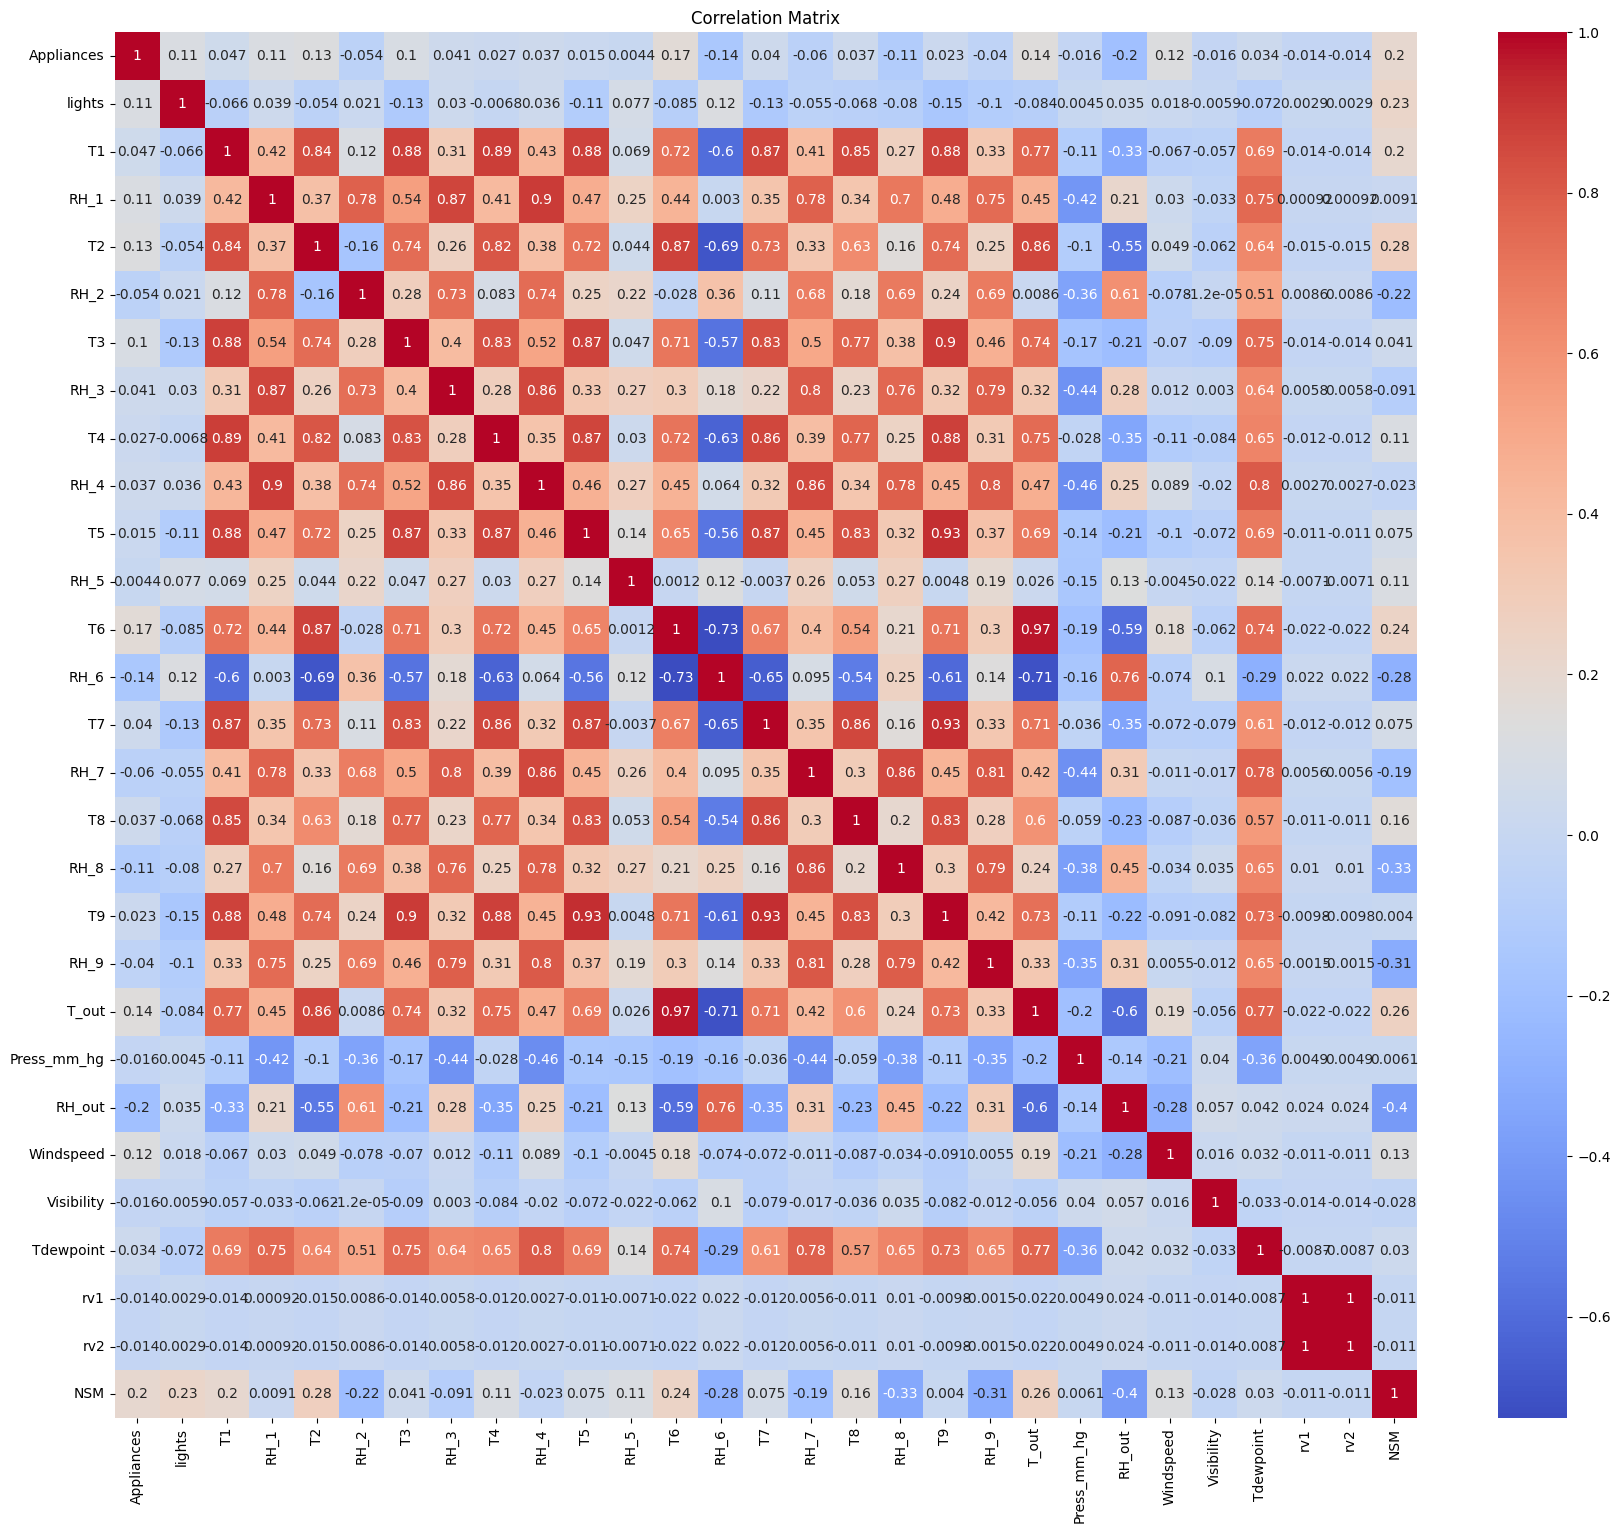

NSM          0.203718
RH_out       0.197888
T6           0.165871
RH_6         0.144340
T_out        0.143548
T2           0.125841
Windspeed    0.124067
lights       0.113350
RH_8         0.112096
RH_1         0.109805
Name: Appliances, dtype: float64

In [9]:
# ploting the correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(21, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# extract the top 10 correlations with Appliances
appliances_corr = corr_matrix['Appliances']

sorted_appliances_corr = appliances_corr.drop('Appliances').abs().sort_values(ascending=False)

top_10_appliances_corr = sorted_appliances_corr.head(10)
top_10_appliances_corr

Insight from the heatmap and top 10 for feature selection: 
* RH_out and T_out are in top 10, but also correlated with each other (-0.6) -> should only keep the one that is more correlated with Appliances -> keeping RH_out 
* RH_out, RH_6, RH_8, RH_1 are in top 10, but also correlated with each other -> should only keep the one that is more correlated with Appliances -> keeping RH_out.
* T6 and T2 are in top 10, but also correlated with each other (-0.87) -> should only keep the one that is more correlated with Appliances -> keeping T6 

* Conclusion ***NSM, RH_out, Windspeed, lights, T6 will be retained*** for ***MULTIVARIATE*** models

In [10]:
# Then we can select features depending on the previous explanation (Pham 2025)
df = df[['Appliances', 'NSM', 'RH_out', 'Windspeed', 'lights', 'T6']]
df.head()

,Appliances,NSM,RH_out,Windspeed,lights,T6
date,,,,,,
2016-02-14 00:00:00,50,0.0,98.000000,2.000000,10,3.530000
2016-02-14 00:10:00,50,600.0,98.166667,2.166667,0,3.466667
2016-02-14 00:20:00,60,1200.0,98.333333,2.333333,10,3.400000
2016-02-14 00:30:00,40,1800.0,98.500000,2.500000,0,3.400000
2016-02-14 00:40:00,60,2400.0,98.666667,2.666667,10,3.400000


#### 2.3. Plot the time series for appliances

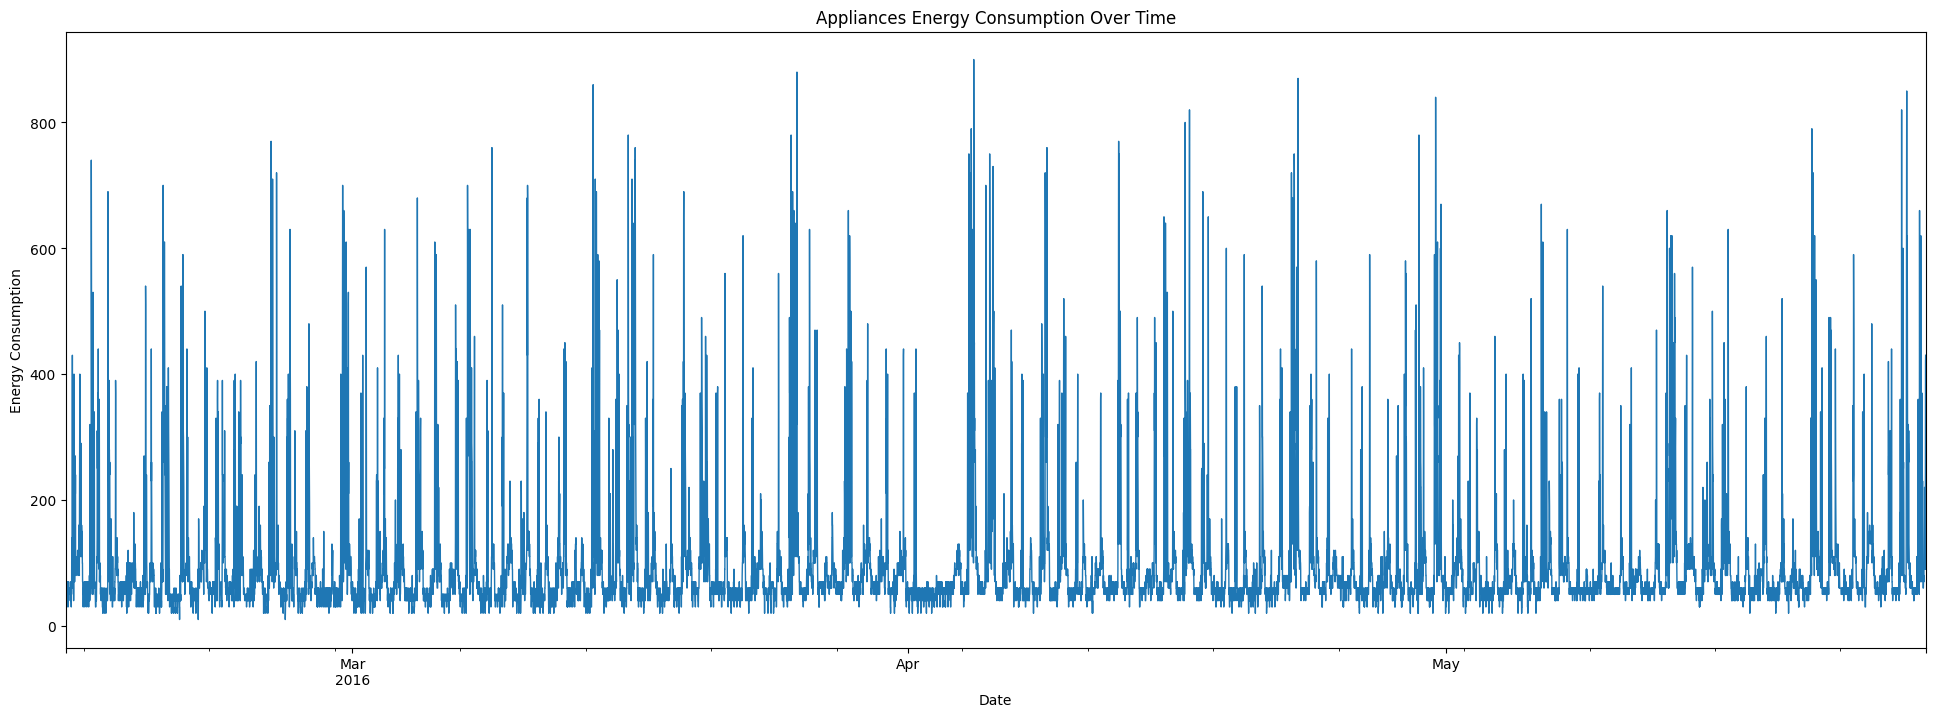

In [12]:
df['Appliances'].plot(figsize=(24, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.show()

As can be seen above, the time series does not yield any obvious trend on energy usage (Appliances) overtime. However, the absence of pattern does not necessarily imply that the data is stable. For further stationary checking, let's plot the simple ***moving average***. According to **Module 5**, moving average is a technique used to smooth out the data. It is used to identify the underlying trend in the data. We will use the rolling method to calculate the moving average of the Appliances column

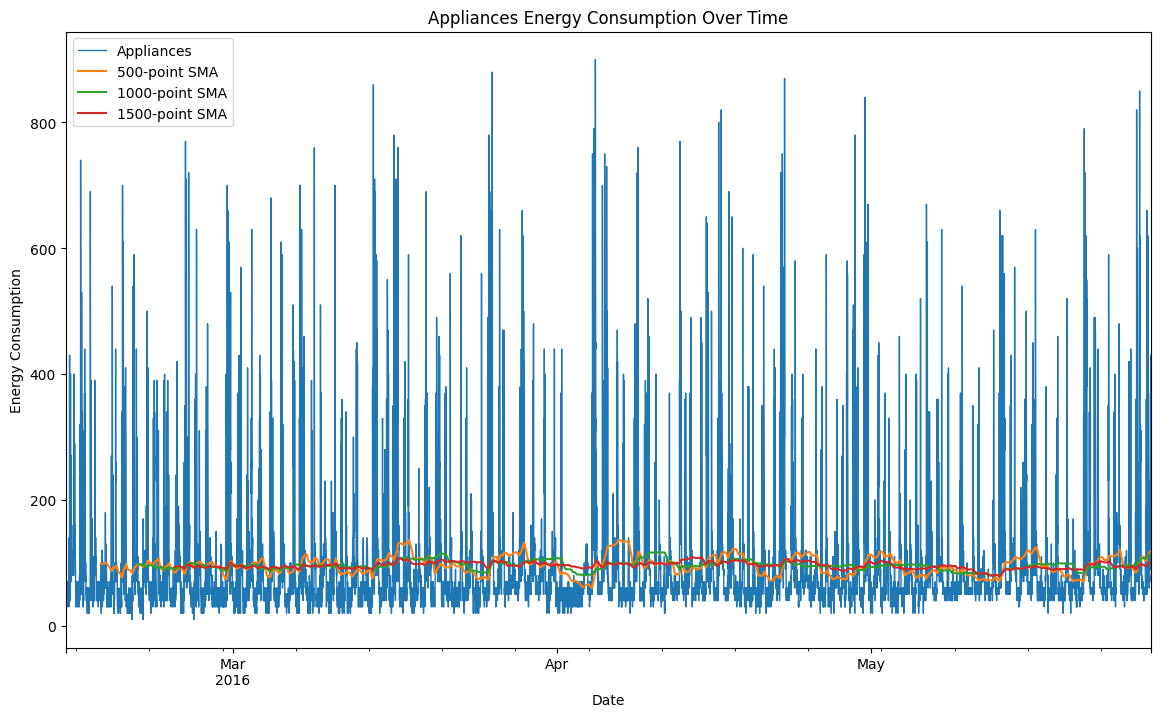

In [13]:

# Average Appliances per 500 1000 and 1500 data points
df_sma_500 = df['Appliances'].rolling(window=500).mean()
df_sma_1000 = df['Appliances'].rolling(window=1000).mean()
df_sma_1500 = df['Appliances'].rolling(window=1500).mean()

df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
df_sma_500.plot(label='500-point SMA')
df_sma_1000.plot(label='1000-point SMA')
df_sma_1500.plot(label='1500-point SMA')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()

As can be seen from the plot, larger window (moving average) results in more short-term fluctuation reduction but still flat. The original energy consumptions is fluctuated while three of SMAs are quite stable.

#### 2.4. Stationary checking

There is another more statistical way to determine stationary checking, Augmented Dickey-Fuller test (ADF). <br>
According to (nageshsingh 2021), **ADF** is well-known for determining the presence of unit root in the series. Let's define null and alternate hypothesis of this stationary check:
* **Null Hypothesis**: The series has a unit root.
* **Alternate Hypothesis**: The series has no unit root. <br>
If the p-value is smaller than 0.05 we can reject the Null Hypothesis

In [14]:
result = adfuller(df['Appliances']) 
print('ADF Statistic:', result[0])
print('p-value:', round(result[1], 4))

ADF Statistic: -17.91666231083487
p-value: 0.0


We can see that p-value is smaller than 0.05, which again consolidates even more the previous assumption, the time series is ***stationary***! This insight will be valuable for ***UNIVARIATE*** models

#### 2.5. Outlier checking

In the previous Appliances boxplot, we can see that there are outliers in the data, indicating that other features also have outliers

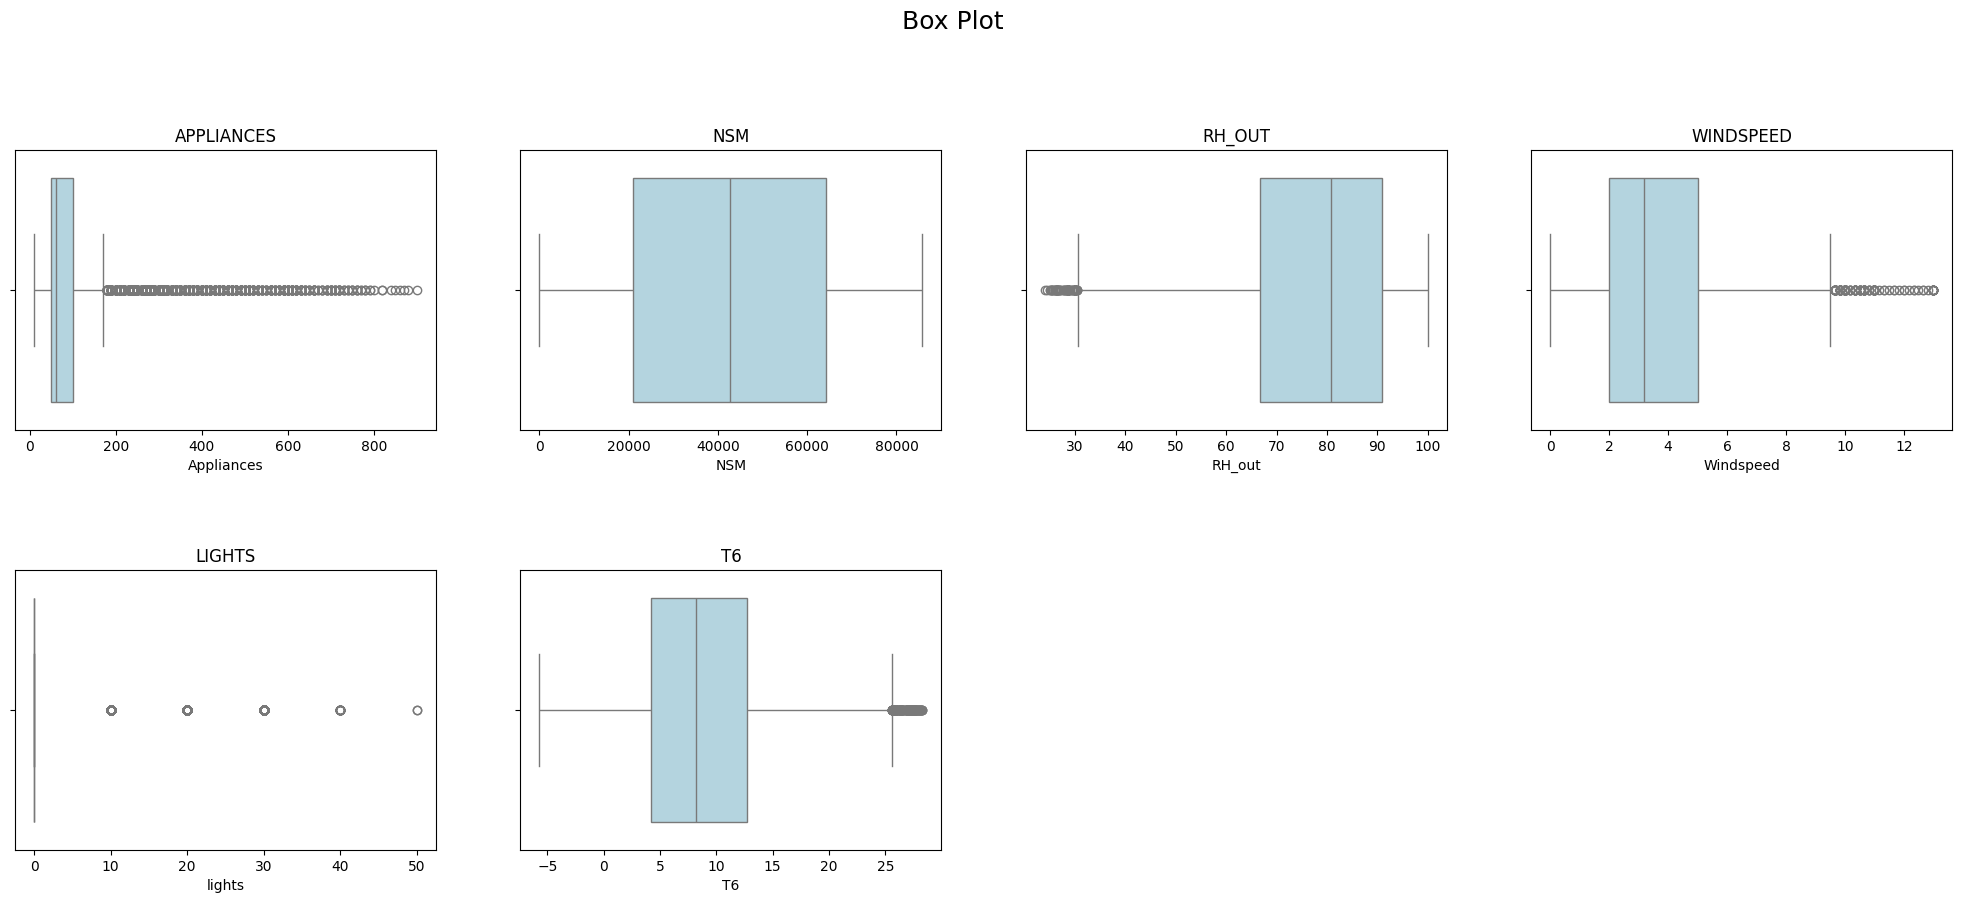

In [15]:
col_list = list(df.describe().columns)

plt.figure(figsize=(25, 20))
plt.suptitle("Box Plot", fontsize=18, y=0.95)

for n, ticker in enumerate(col_list):

    ax = plt.subplot(4, 4, n + 1)

    plt.subplots_adjust(hspace=0.5, wspace=0.2)

    sns.boxplot(x=df[ticker], color='lightblue', ax=ax)

    # chart formatting
    ax.set_title(ticker.upper())

As can be seen from the plot, we have a lot of outliers in the other features also. Outlier removal is needed.

### 3. Pre-process the data
This is a important part of the time series forecasting task. We should be careful with data spliting and data scaling, which might lead to data leaking. To avoid that, this section includes: 
1. Handle outliers
2. Split data into three sets train, dev, test
3. Scale data

#### 3.1 Handle outliers
We are going to handle outliers by clipping values outside the lower and upper bounds

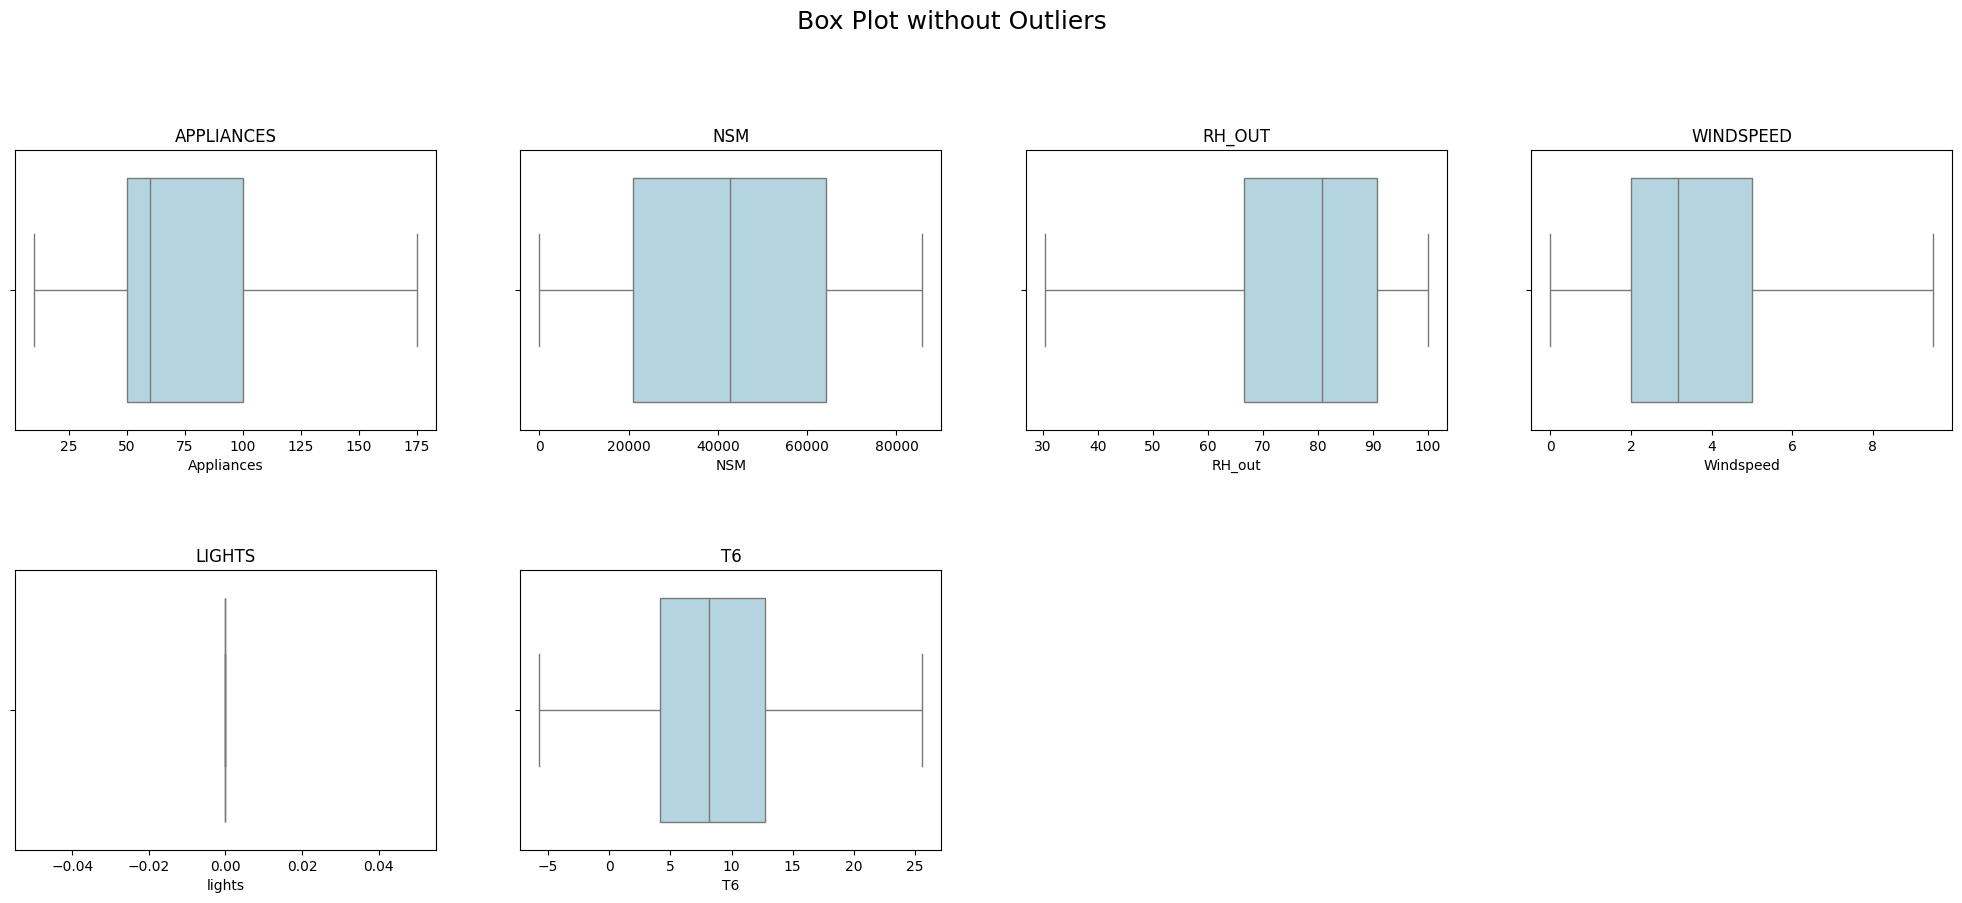

In [16]:
def handle_outliers(df, column):
    # Calculate Q1 for the given feature
    Q1 = df[column].quantile(0.25)
    
    # Calculate Q3 for the given feature
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate lower and upper bounds for the given feature
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Clip values outside the lower and upper bounds
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Clip outliers
columns_to_check = df.describe().columns
for col in columns_to_check:
    df = handle_outliers(df, col)

col_list = list(df.describe().columns)

plt.figure(figsize=(25, 20))
plt.suptitle("Box Plot without Outliers", fontsize=18, y=0.95)

# Plot after removing outliers
for n, ticker in enumerate(col_list):

    ax = plt.subplot(4, 4, n + 1)

    plt.subplots_adjust(hspace=0.5, wspace=0.2)

    sns.boxplot(x=df[ticker], color='lightblue', ax=ax)

    # chart formatting
    ax.set_title(ticker.upper())

After handling outliers of LIGHTS, its values seems to be all 0, we should remove this feature

In [17]:
df = df.drop('lights', axis=1)

#### 3.2. Split data into three sets train, dev, test
Only after handling all outliers, we can split data into train, dev, test. This process needs to be done in time order. 

In [18]:

# Split data into train_dev and test sets (time series split)
train_dev_size = int(len(df) * 0.75)
df_train_dev = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

# Further split train_dev into train and dev sets
train_size = int(len(df_train_dev) * 0.8)
df_train = df_train_dev.iloc[:train_size]
df_dev = df_train_dev.iloc[train_size:]

# Print the shapes of the train, dev, and test sets
print('Train Set:', df_train.shape)
print('Dev Set:', df_dev.shape)
print('Test Set:', df_test.shape)


Train Set: (8964, 5)
Dev Set: (2241, 5)
Test Set: (3736, 5)


#### 3.3. Scale data
As Sigmoid or Tanh activation in LSTM is sensitive to values between 0 and 1, we are going to use ***MinMaxScaler*** to scale the data falls between 0 and 1 (Brownlee 2019).

In [19]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler on the training set and transform all sets
scaled_train = scaler.fit_transform(df_train)
scaled_dev = scaler.transform(df_dev)
scaled_test = scaler.transform(df_test)

# Univariate time series data
scaler_uni = MinMaxScaler(feature_range=(0, 1))
scaler_uni = scaler_uni.fit(df_train['Appliances'].values.reshape(-1, 1))

# Convert back to DataFrame if needed. ONLY USE scaled data for LSTM, not ARIMA
df_train_scaled = pd.DataFrame(scaled_train, columns=df_train.columns, index=df_train.index)
df_dev_scaled = pd.DataFrame(scaled_dev, columns=df_dev.columns, index=df_dev.index)
df_test_scaled = pd.DataFrame(scaled_test, columns=df_test.columns, index=df_test.index)


### 4. Model Training and Selection

In this section, two models have been chosen for the experiment:  

1. **ARIMA (univariate)**  
2. **LSTM (multivariate)**  

##### **ARIMA (AutoRegressive Integrated Moving Average)**  
ARIMA is a powerful time series forecasting method that combines:  
- **Autoregression (AR)** – Uses past values to predict future values.  
- **Differencing (I)** – Removes trends to make the series stationary.  
- **Moving Average (MA)** – Smooths out noise by averaging past errors.  

*(Siami Namin & Siami Namin, 2018)*  

##### **LSTM (Long Short-Term Memory)**  
LSTM mitigates the vanishing/exploding gradient problem as it has both **long-term and short-term memory**, making it effective for sequential data.  

*(Staudemeyer & Morris, 2019)* . LSTM can handle both multivariate time series data, meaning they can process multiple input features (columns) or univariate time series data (just the Appliances column). In this report, we will be implementing LSTM in the multivariate manner.

##### **Evaluation Metrics**  
To compare ARIMA and LSTM, we will use the following metrics:  

- **Mean Absolute Percentage Error (MAPE)**  
  - Measures prediction accuracy relative to actual values in percentage terms.  
  - Since ARIMA and LSTM operate differently, MAPE provides a **common ground** for fair performance evaluation.  

- **Root Mean Squared Error (RMSE)**  
  - Measures the **average magnitude of prediction error**, giving higher weight to larger errors.  
  - Suitable for our time series predictions since **we want to minimize large errors**. For this energy prediction task, energy varies from large to small. Giving higher weight to larger errors can help prediction peak hours easily


#### 4.1. ARIMA

As we already concluded that the data is stationary, ARIMA can be used to timeseries forecasting. Let's break down the process to initialize the model:
1. Decompose 
2. Determining ARIMA parameter p, d, q
3. Evaluate

##### 4.1.1. Decompose

Decomposing will separate the time series into trend, seasonality, and residuals. Decomposing not only helps us understanding the patterns hidden in the data, but also helps ARIMA model to forecast more accurately.

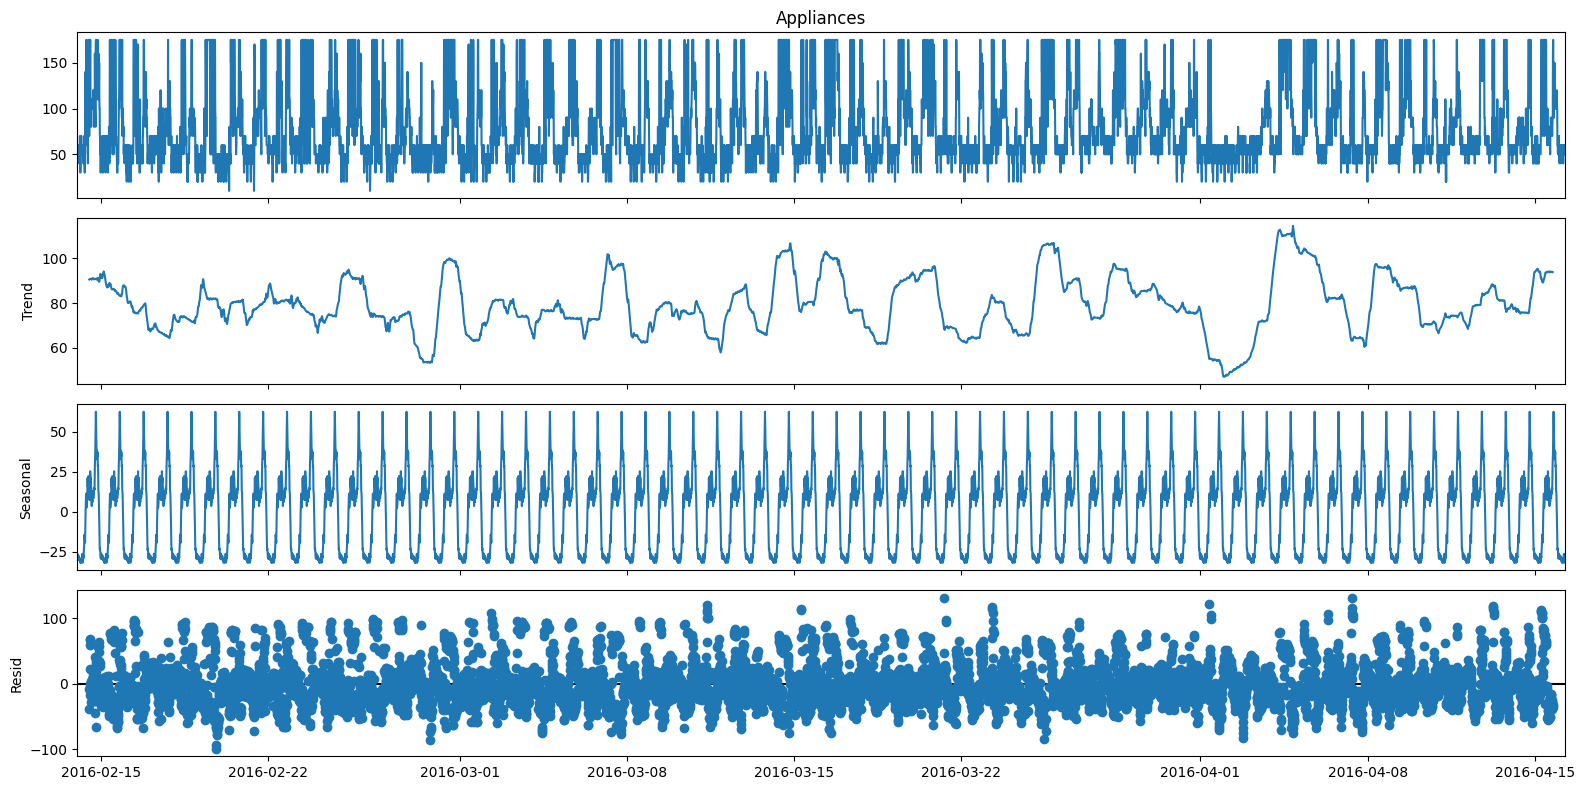

In [21]:
# Decomposition
rcParams['figure.figsize'] = 16, 8

decomposition = seasonal_decompose(df_train['Appliances'], model='additive', period=144) #24*60/10=144 Daily data
decomposition.plot()
plt.show()

# Extract the trend, seasonal, and residual components
residual = decomposition.resid
seasonal = decomposition.seasonal
trend = decomposition.trend

* ***Trend*** is the overall direction overtime of the time series, we can see if the series is up, down or stable
* ***Seasonality*** shows the repeating pattern of the time series at fix interval
* ***Residuals*** (Error) is the random fluctuation that is left over after extracting Trend and Seasonality. Residuals might not be pure white error, meaning they can still contain useful information. We can model ARIMA and fit on this information later on.

##### 4.1.2. Determining ARIMA parameter p, d, q
* ***p (AR - Auto Regressive)***: This component uses past values (lags) to predict the future values. But it requires a stationary time series, which is why ARIMA has **(I - Integrated)** part. We can determine the value of p by *PACF (Partial Autocorrelation Function)*
* ***(I - Integrated)***: This component will determine how much *differencing* needed to make the time series stationary.
* ***MA (Moving Average)***: This compoment uses past forecast errors (the difference between predicted and actual values) to improve future predictions.  We can determine the value of p by *ACF (Autocorrelation Function)*

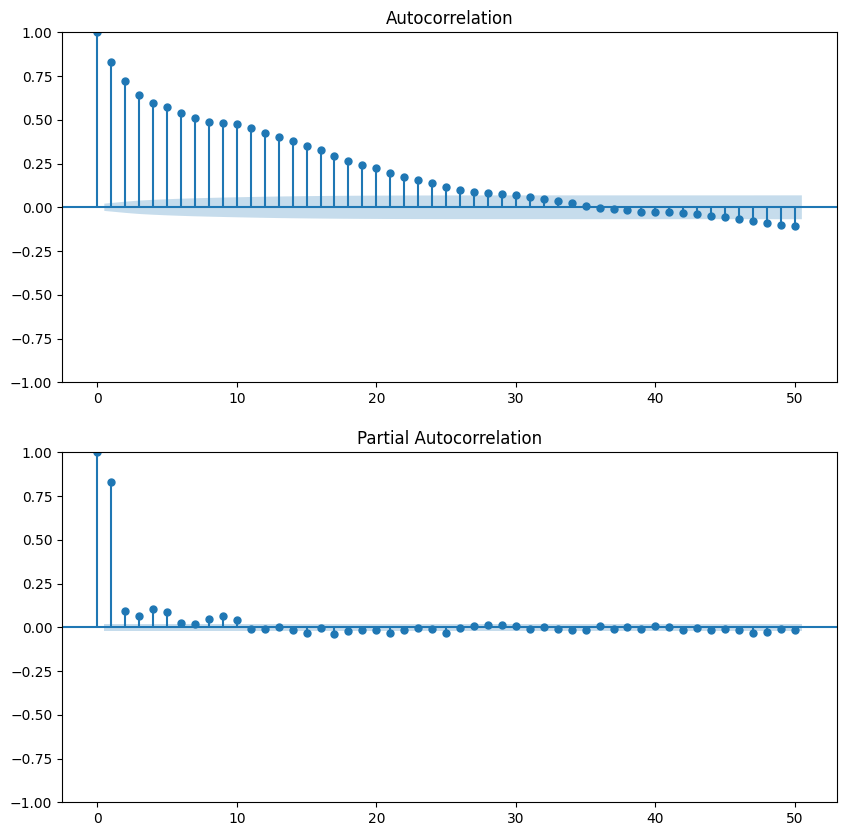

In [22]:
# Finding p and q values using ACF and PACF plots
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

plot_acf(df_train['Appliances'], lags=50, ax=ax[0])
plot_pacf(df_train['Appliances'], lags=50, ax=ax[1])
plt.show()

***ARIMA Model Selection*** 

Based on the **Partial Auto-Correlation Function (PACF) plot** and the guidelines from *MBD_lecture 5 part 2*, we decide the ARIMA model parameters as follows:  

- **Autoregressive (AR) order (p)**:  
  - The **PACF** cuts off significantly at lag **2**.  
  - This suggests an AR(2) process.  
  - **Chosen value: `p = 2`**  

- **Moving Average (MA) order (q)**:  
  - The **ACF** decays gradually, rather than cutting off at a specific lag.  
  - This suggests no strong MA component.  
  - **Chosen value: `q = 0`**  

- **Differencing order (d)**:  
  - The data is already **stationary**, as confirmed by statistical tests and visualizations.  
  - No differencing is needed.  
  - **Chosen value: `d = 0`**  

Final ARIMA Model: **ARIMA(2,0,0)**  

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                 8964
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -39994.766
Date:                Sat, 22 Mar 2025   AIC                          79997.531
Time:                        22:38:01   BIC                          80025.935
Sample:                    02-14-2016   HQIC                         80007.198
                         - 04-16-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      1.004      0.005      0.996      -1.963       1.973
ar.L1          0.6803      0.008     80.349      0.000       0.664       0.697
ar.L2          0.0392      0.007      5.626      0.0

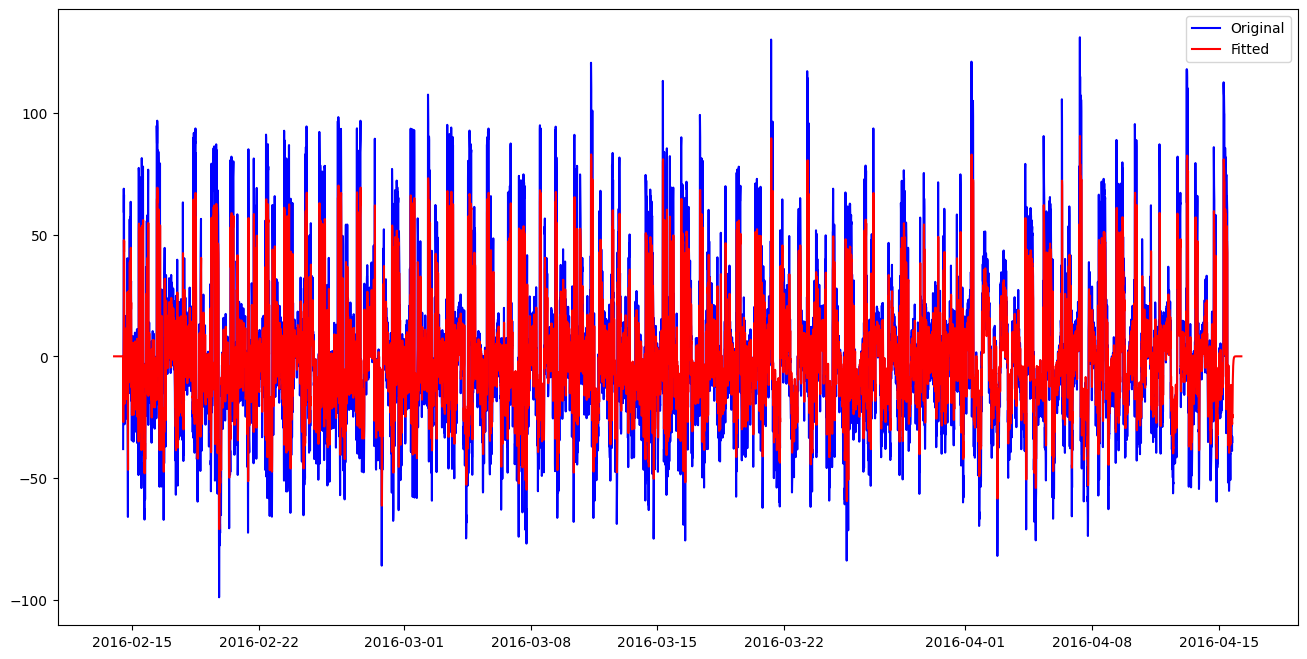

In [23]:
# Fit ARIMA model after choosing p d q values

model_arima = sm.tsa.arima.ARIMA(residual, order=(2, 0, 0)) 
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())
plt.plot(residual, label='Original', color='blue')
plt.plot(model_arima_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

##### 4.1.3. Evaludate
The model performs quite well on the training process, let's plot its prediction on the dev set.

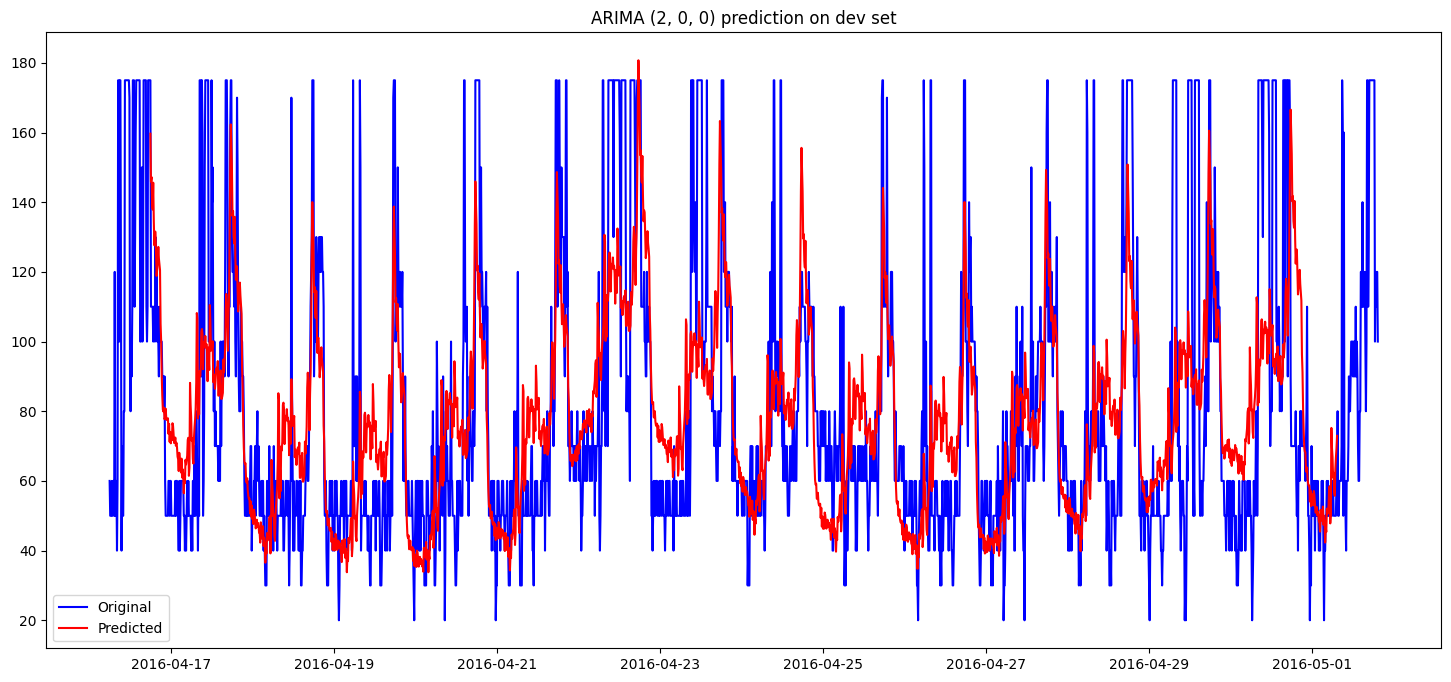

In [24]:
# First, we need to decompose the dev set similar to the training set
dev_decomposition = seasonal_decompose(df_dev['Appliances'], model='additive', period=144)
dev_residual = dev_decomposition.resid
dev_seasonal = dev_decomposition.seasonal
dev_trend = dev_decomposition.trend

# Drop NaN values from residual
dev_residual = dev_residual.interpolate(method='linear') 

# Now we need to ensure we use the same index for all components
common_index = dev_residual.index

# Make predictions using the fitted ARIMA model
dev_predictions_residual = model_arima_fit.forecast(steps=len(dev_residual))

# Align indices before adding components
# Convert the forecast to a Series with the same index as dev_residual
dev_predictions_residual = pd.Series(dev_predictions_residual, index=common_index)

# Use the same index for all components
dev_predictions_complete = dev_predictions_residual + dev_seasonal.loc[common_index] + dev_trend.loc[common_index]

# Plotting
plt.figure(figsize=(18, 8))
plt.plot(df_dev['Appliances'].loc[common_index], label='Original', color='blue')
plt.plot(dev_predictions_complete, label='Predicted', color='red')
plt.title('ARIMA (2, 0, 0) prediction on dev set')
plt.legend()
plt.show()

In [25]:
# Calculate error
def evaluate(y_true, y_pred, scaler=None):
    if scaler:
        y_true = scaler.inverse_transform(y_true)
        y_pred = scaler.inverse_transform(y_pred)
    
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mape

# Because period=144, so we have missing values at the end and the beginning of the residual
# We need to remove these missing values to ensure alignment
valid_mask = ~np.isnan(df_dev['Appliances']) & ~np.isnan(dev_predictions_complete)

# Filter non-NaN values
y_true = df_dev['Appliances'][valid_mask]
y_pred = dev_predictions_complete[valid_mask]

# Calculate RMSE and MAPE
rmse_arima, mape_arima = evaluate(y_true, y_pred)

# print(f'RMSE: {rmse_arima}')
# print(f'MAPE: {mape_arima}')

RMSE: 29.447978957331014
MAPE: 30.786773019386654


#### 4.2. LSTM
This sections includes:
1. Pre-process the data
2. Initialize the model 
3. Train the model
3. Evaluate

##### 4.2.1 Pre-process the data
Multivariate LSTM requires extra steps before we can train it.
* In time series forcasting, we can expand out data for another dimension, meaning that we will train LSTM with **x** number of observations for each step, named ***look_back***. 
* Because we will be using Pytorch to build the model, we need to transform the our data into ***Tensor***


In [82]:
# Function to create dataset
def create_XY_lstm(df, look_back=1):
    """
    Create X and Y datasets for LSTM
    Parameters
    ----------
    df : DataFrame
        DataFrame to create datasets from
    look_back : int
        Number of previous observations to consider
    Return numpy arrays of X and Y
    -------
    """
    dataX, dataY = [], []
    
    for i in range(look_back, len(df)):
        feature = df.iloc[i - look_back:i, 0:df.shape[1]].values  # Convert DataFrame to NumPy array
        target = df.iloc[i, df.columns.get_loc('Appliances')]
        
        dataX.append(feature)
        dataY.append(target)

    return np.array(dataX), np.array(dataY)


lookback = 3  # Number of previous observations to consider
X_train, y_train = create_XY_lstm(df_train_scaled, lookback)
X_dev, y_dev = create_XY_lstm(df_dev_scaled, lookback)

print(f"X_train shape: {X_train.shape}")  # Should be [observations, lookback, features]
print(f"y_train shape: {y_train.shape}")  # Should be [observations]
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")

X_train shape: (8961, 3, 5)
y_train shape: (8961,)
X_dev shape: (2238, 3, 5)
y_dev shape: (2238,)


In [84]:
# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_dev = torch.tensor(X_dev, dtype=torch.float32)
y_dev = torch.tensor(y_dev, dtype=torch.float32)

##### 4.2.2. Initialize the model 
LSTM is one variation of RNN, but more robust on mitigating vanishing/exploding gradient. LSTM contains cells, each cell consists of three main components: a cell state, hidden state, and gates. These gates are:
1. Forget Gate: Decides how much of the previous cell state should be *forgotten*
2. Input Gate: Decide how much of the hidden state should be *input* to the cell state
3. Output Gate: Decide how much of the hidden state should be *output* <br>

The *how much* term from above will be defined using activation such as **Sigmoid**, which can be interpreted as ***percentage***.<br>
<br>

Here, we do not have to build LSTM from scratch. Our LSTM has 

In [85]:
class MyLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super(MyLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, X):
        batch_size = X.shape[0]

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)

        # Forward pass through LSTM
        lstm_out, _ = self.lstm(X, (h0, c0))
        
        # Apply the linear layer to the last time step's output
        predictions = self.linear(lstm_out[:, -1, :])
        
        return predictions  # Shape: [batch_size, output_size]

Chosing parameters for LSTM is quite challenging. After trying different values for the number of layers and the hidden layer size, we found that these following values works best with the dataset.

In [86]:
# Choose device
# device = 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
hidden_layer_size = 50
output_size = 1
num_layers = 3
n_epochs = 200
learning_rate = 0.0001

model = MyLSTM(X_train.shape[2], hidden_layer_size, output_size, num_layers).to(device)
model

MyLSTM(
  (lstm): LSTM(5, 50, num_layers=3, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

##### 4.2.3. Train the model
Mean Square Error (MSE) is appropriate for regression task. It penalizes large errors, helps the model reduce significant error. As we can see from the previous discussion. For our task, energy prediction, this can be good if the larger values have higher importance.

Epoch [10/200], Train Loss: 0.2312, Val Loss: 0.2325
Epoch [20/200], Train Loss: 0.2191, Val Loss: 0.2201
Epoch [30/200], Train Loss: 0.2072, Val Loss: 0.2079
Epoch [40/200], Train Loss: 0.1953, Val Loss: 0.1958
Epoch [50/200], Train Loss: 0.1835, Val Loss: 0.1836
Epoch [60/200], Train Loss: 0.1714, Val Loss: 0.1711
Epoch [70/200], Train Loss: 0.1590, Val Loss: 0.1584
Epoch [80/200], Train Loss: 0.1463, Val Loss: 0.1453
Epoch [90/200], Train Loss: 0.1334, Val Loss: 0.1318
Epoch [100/200], Train Loss: 0.1203, Val Loss: 0.1182
Epoch [110/200], Train Loss: 0.1073, Val Loss: 0.1048
Epoch [120/200], Train Loss: 0.0950, Val Loss: 0.0920
Epoch [130/200], Train Loss: 0.0842, Val Loss: 0.0806
Epoch [140/200], Train Loss: 0.0756, Val Loss: 0.0717
Epoch [150/200], Train Loss: 0.0701, Val Loss: 0.0659
Epoch [160/200], Train Loss: 0.0677, Val Loss: 0.0631
Epoch [170/200], Train Loss: 0.0672, Val Loss: 0.0624
Epoch [180/200], Train Loss: 0.0672, Val Loss: 0.0623
Epoch [190/200], Train Loss: 0.0672, 

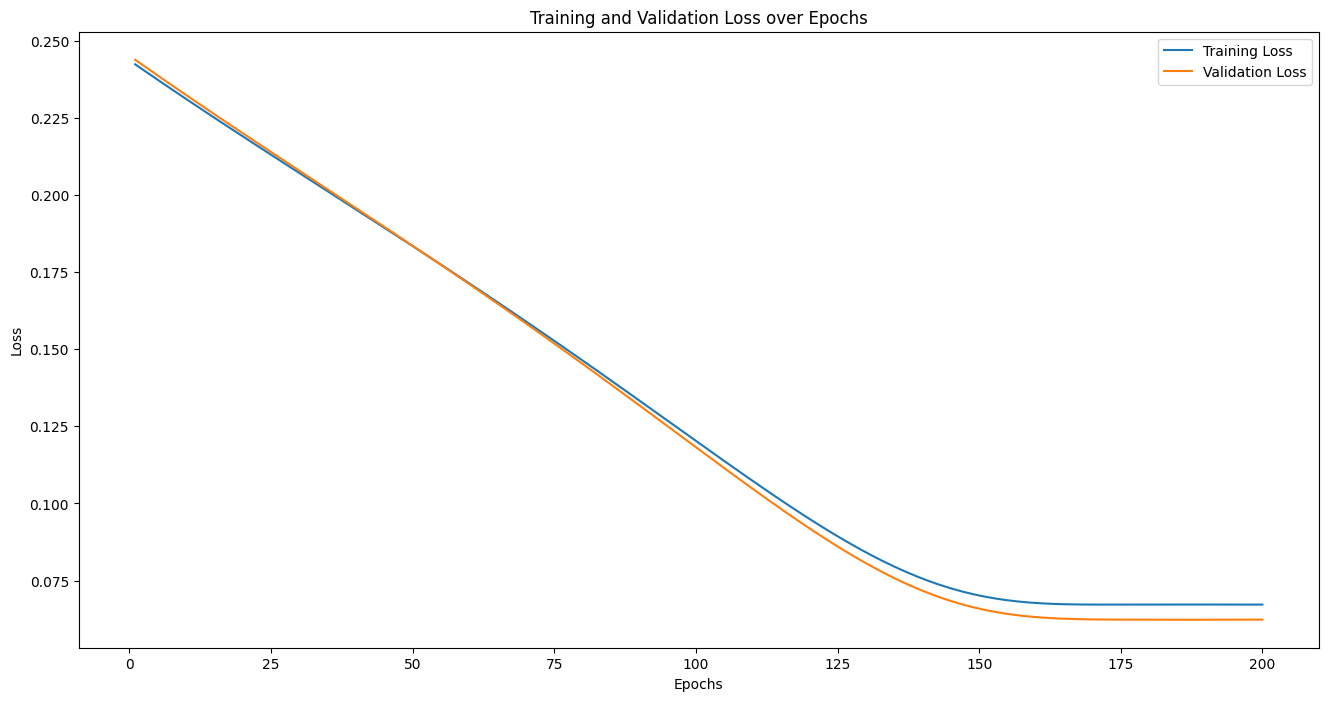

In [87]:
criterion = nn.MSELoss()  # mse
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store the loss at each epoch
train_losses = []
val_losses = []

# Training loop
for epoch in range(n_epochs):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Clear previous gradients
    
    # Forward pass (training)
    y_pred = model(X_train.to(device))
    
    # Calculate loss (training loss)
    train_loss = criterion(y_pred, y_train.to(device))
    
    # Backward pass (training)
    train_loss.backward()  # Compute gradients
    
    # Update weights
    optimizer.step()
    
    # Append the training loss to the list
    train_losses.append(train_loss.item())
    
    # Calculate validation loss after each epoch
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # No need to track gradients during evaluation
        y_val_pred = model(X_dev.to(device))
        val_loss = criterion(y_val_pred, y_dev.to(device))
    
    # Append the validation loss to the list
    val_losses.append(val_loss.item())
    
    # Print the losses at intervals
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')


# Plot the training and validation loss
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()


As can be seen, it converges after 100 epochs, and the loss is quite promissing with just around 0.075 on the dev set. Let's plot the prediction

##### 4.2.4. Evaluate
First we are goint to plot the prediction of LSTM on the dev set, and then compare the results with ARIMA

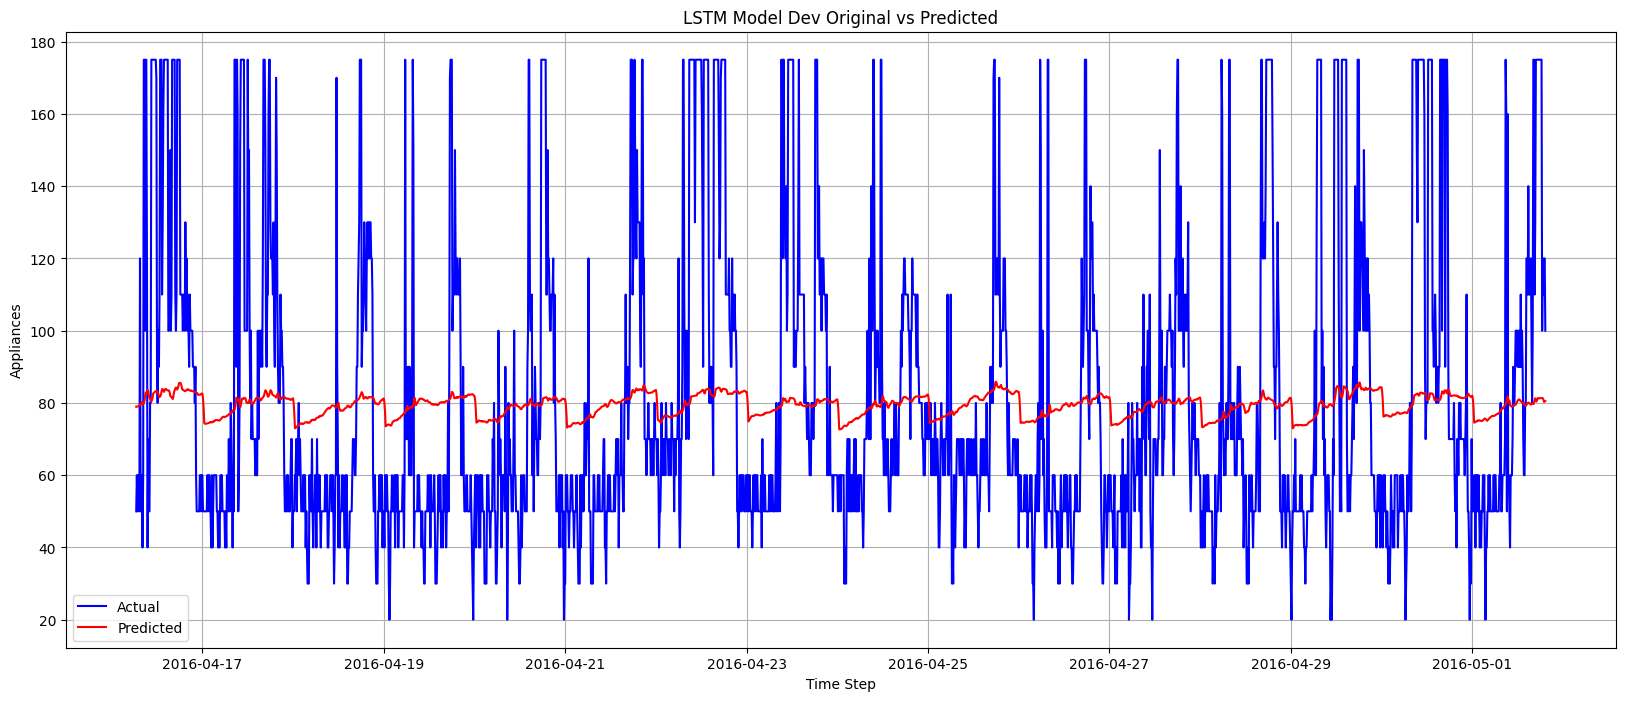

In [88]:
#  Predict
model.eval()
with torch.no_grad():
    y_pred_dev = model(X_dev.to(device)) # output: [observations, 1]

# convert to numpy for inverse scaling
y_pred_dev = y_pred_dev.to('cpu').numpy()

# Concatenate columns to match the original data before inverse scaling
y_pred_dev_inv = np.concatenate((y_pred_dev, np.zeros((y_pred_dev.shape[0], df_dev_scaled.shape[1] - 1))), axis=1)

# Inverse scaling
y_pred_dev_inv = scaler.inverse_transform(y_pred_dev_inv)[:, 0]
y_dev_inv = scaler.inverse_transform(np.concatenate((y_dev.reshape(-1, 1), np.zeros((y_dev.shape[0], df_dev_scaled.shape[1] - 1))), axis=1))[:, 0]

# Excluding the lookback period as we used it to predict the first value
time_steps = df_dev.index[lookback:]

# Plot the results
plt.figure(figsize=(20, 8))
plt.plot(time_steps, y_dev_inv, label='Actual', color='blue')
plt.plot(time_steps, y_pred_dev_inv, label='Predicted', color='red')
plt.xlabel('Time Step')
plt.ylabel('Appliances')
plt.title('LSTM Model Dev Original vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [89]:
# Calculate RMSE and MAPE
rmse_lstm, mape_lstm = evaluate(y_dev_inv, y_pred_dev_inv)

print(f'RMSE: {rmse_lstm}')
print(f'MAPE: {mape_lstm}')

RMSE: 39.73056164119497
MAPE: 42.56475329007388


As can be seen from the line plot, LSTM performs poorly on the dev set. We were expecting LSTM to perform the best. One potential reason could be there are too many feaures. Including a unecessary features might introduce more **noise** instead of meaningful information for energy usage prediction. It led to overfitting. More feature engineering might solve this problem

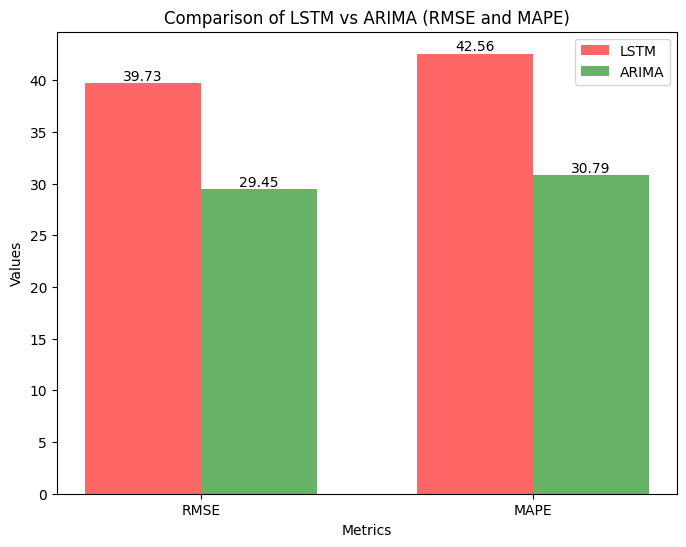

In [90]:
metrics_names = ['RMSE', 'MAPE']
lstm_metrics = [rmse_lstm, mape_lstm]
arima_metrics = [rmse_arima, mape_arima]

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Bar plot for LSTM and ARIMA
bar_width = 0.35
index = range(len(metrics_names))

# Plot LSTM and ARIMA metrics side by side
lstm_bars = ax.bar(index, lstm_metrics, bar_width, label='LSTM', color='red', alpha=0.6)
arima_bars = ax.bar([i + bar_width for i in index], arima_metrics, bar_width, label='ARIMA', color='green', alpha=0.6)

# Set labels and title
ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Comparison of LSTM vs ARIMA (RMSE and MAPE)')

# Set x-axis labels
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(metrics_names)

# Add legend
ax.legend()

# Add values on top of the bars
for bar in lstm_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', color='black')

for bar in arima_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', color='black')

# Show plot
plt.show()


* While RMSE tells us how much different the predicted energy values and the actual values **on average** is, MAPE represents error in terms of percentage about how much the model predictions deviate from the actual. We want both of those values to be low, which means **ARIMA is performing better** on the dataset.

* **ARIMA is more accurate** in this case. That might be due to the **stationarity** of the data. Energy has an obvious pattern, as discussed, so we might not need a complex model like multivariate LSTM for this task.


### 5. Testing and analysis of the final model
ARIMA will be chosen for the final model training and evaluation. In this section, we will reuse our code from above (4.1) and follow:
1. Re-split the data
2. Decompose 
3. ARIMA initialization
4. Evaluate
5. Compare to our previous work and Candanedo's work

#### 5.1. Re-split the data
We will split the data into just 2 sets, first 75% of the observation is for training, the rest is for testing. No shuffle is needed

In [12]:
train_dev_size = int(len(df) * 0.75)

df_train = df['Appliances'].iloc[:train_dev_size] 
df_test = df['Appliances'].iloc[train_dev_size:]

print(f"df_train shape: {df_train.shape}")
print(f"df_test shape: {df_test.shape}")

df_train shape: (11205,)
df_test shape: (3736,)


#### 5.2. Decompose 

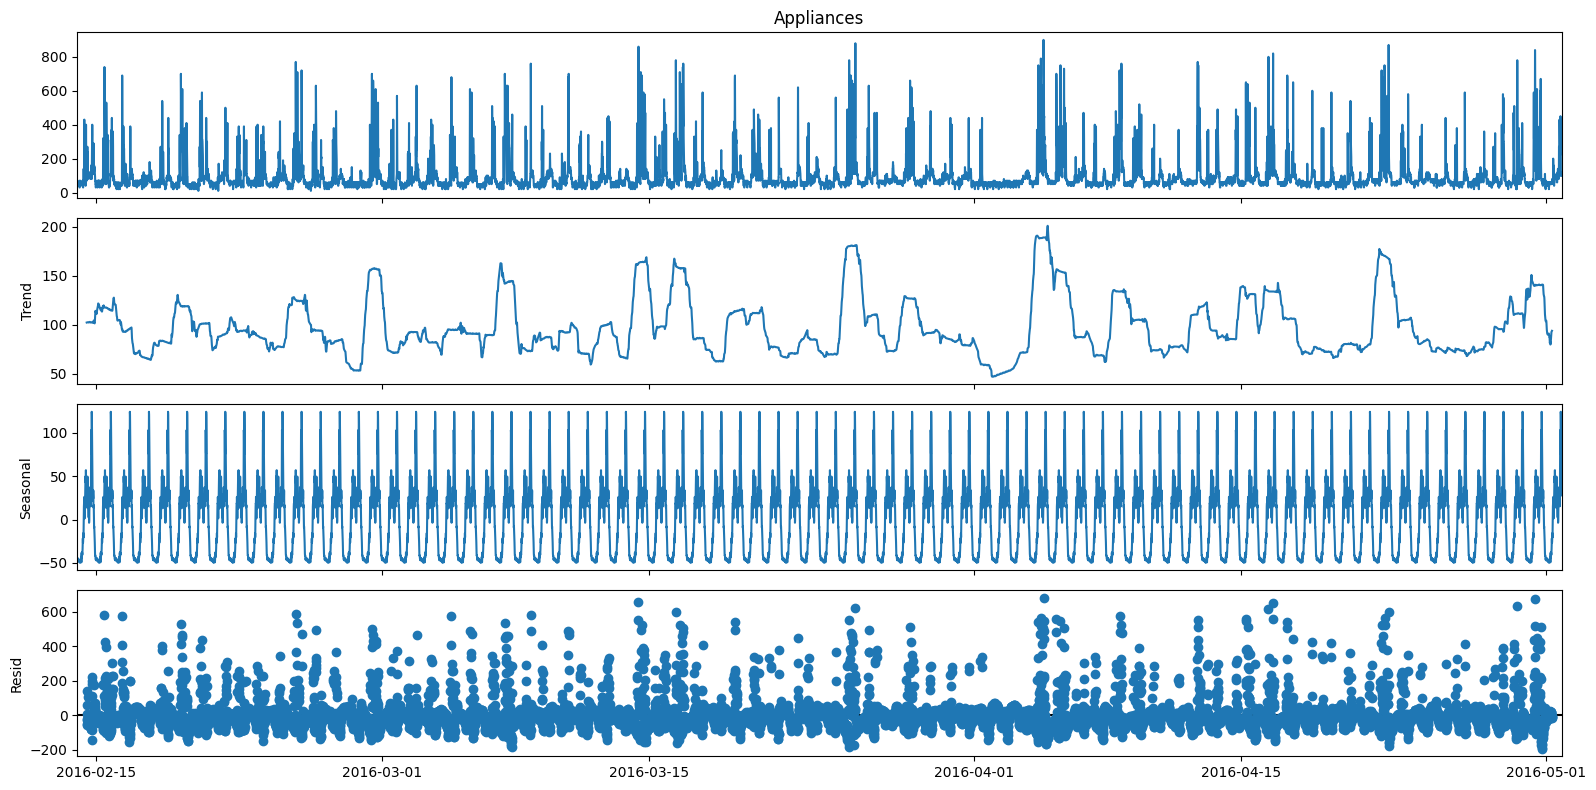

In [13]:
# Decomposition
rcParams['figure.figsize'] = 16, 8

decomposition = seasonal_decompose(df_train, model='additive', period=144) #24*60/10=144 Daily data
decomposition.plot()
plt.show()

# Extract the trend, seasonal, and residual components
residual = decomposition.resid
seasonal = decomposition.seasonal
trend = decomposition.trend

#### 5.3. ARIMA initialization

In [ ]:
model_arima = sm.tsa.arima.ARIMA(residual, order=(2, 0, 0)) 
model_arima_fit = model_arima.fit()

#### 5.4. Evaluate

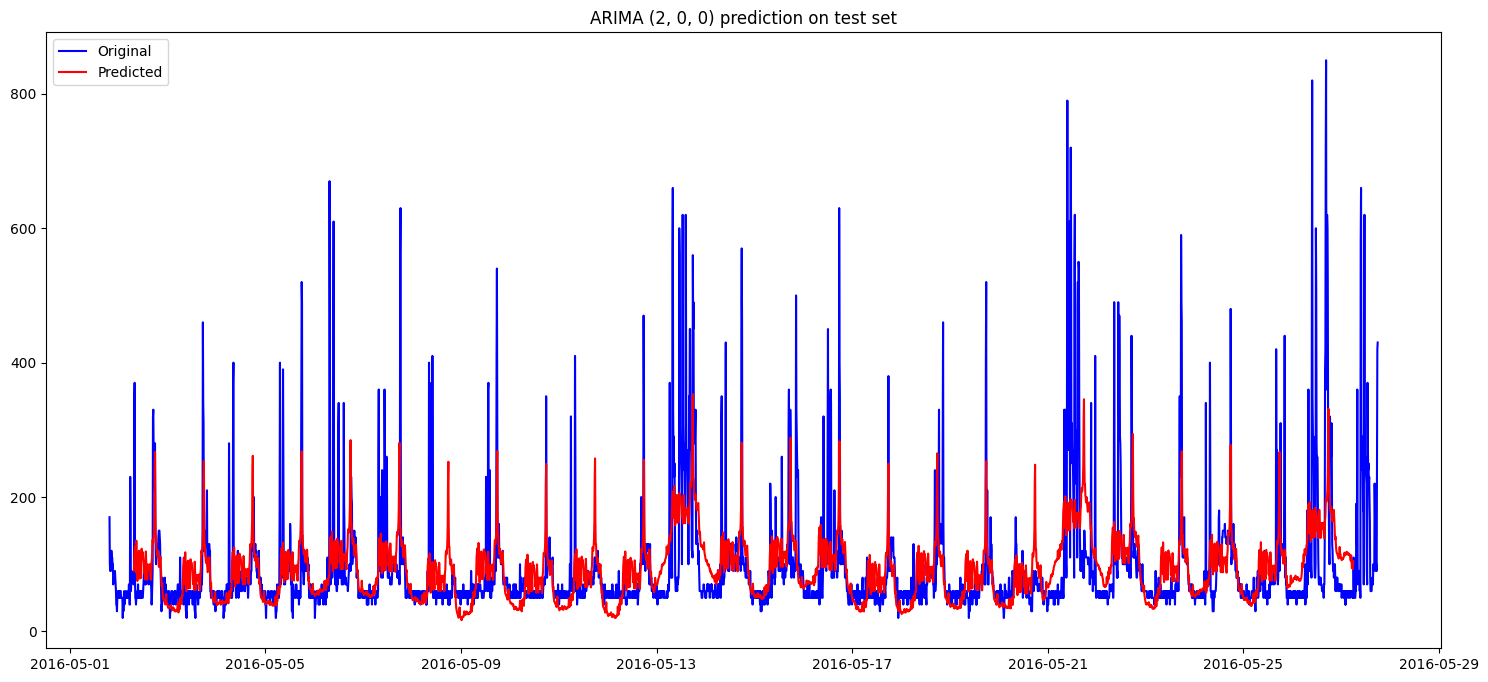

In [16]:
# First, we need to decompose the test set similar to the training set
test_decomposition = seasonal_decompose(df_test, model='additive', period=144)
test_residual = test_decomposition.resid
test_seasonal = test_decomposition.seasonal
test_trend = test_decomposition.trend

# Drop NaN values from residual
test_residual = test_residual.interpolate(method='linear') 

# Now we need to ensure we use the same index for all components
common_index = test_residual.index

# Make predictions using the fitted ARIMA model
test_predictions_residual = model_arima_fit.forecast(steps=len(test_residual))

# Align indices before adding components
# Convert the forecast to a Series with the same index as test_residual
test_predictions_residual = pd.Series(test_predictions_residual, index=common_index)

# Use the same index for all components
test_predictions_complete = test_predictions_residual + test_seasonal.loc[common_index] + test_trend.loc[common_index]

# Plotting
plt.figure(figsize=(18, 8))
plt.plot(df_test.loc[common_index], label='Original', color='blue')
plt.plot(test_predictions_complete, label='Predicted', color='red')
plt.title('ARIMA (2, 0, 0) prediction on test set')
plt.legend()
plt.show()

In [20]:
# Because period=144, so we have missing values at the end and the beginning of the residual
# We need to remove these missing values to ensure alignment
valid_mask = ~np.isnan(df_test) & ~np.isnan(test_predictions_complete)

# Filter non-NaN values
y_true = df_test[valid_mask]
y_pred = test_predictions_complete[valid_mask]

# Calculate RMSE and MAPE
rmse_arima, mape_arima = evaluate(y_true, y_pred)

print(f'Final ARIMA RMSE: {rmse_arima}')
print(f'Final ARIMA MAPE: {mape_arima}')

Final ARIMA RMSE: 70.88827839135361
Final ARIMA MAPE: 43.20887713704036


#### 5.5. Compare to our previous work and Candanedo's work

We have been doing a lot of experiment and model training. Re-running the code just to obtain results is unnecessary, we directly compare RMSE and MAPE values instead of reassigning variables

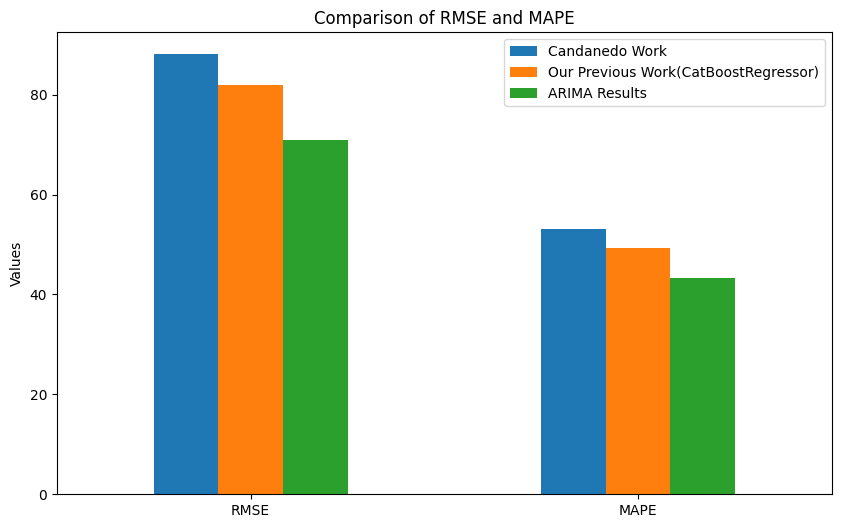

In [23]:
# (ChatGPT 1)
candanedo_work_results = {
    'RMSE': 88.08 , 
    'MAPE': 53.20 
} # (Candanedo, Feldheim & Deramaix 2017b)

our_previous_work_results = {
    'RMSE': 81.87,
    'MAPE': 49.24
} # (Pham 2025)

arima_results = {
    'RMSE': 70.89,
    'MAPE': 43.21
}

# Plotting the comparison of results
results = pd.DataFrame({
    'Candanedo Work': [candanedo_work_results['RMSE'], candanedo_work_results['MAPE']],
    'Our Previous Work(CatBoostRegressor)': [our_previous_work_results['RMSE'], our_previous_work_results['MAPE']],
    'ARIMA Results': [arima_results['RMSE'], arima_results['MAPE']]
}, index=['RMSE', 'MAPE'])

results.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of RMSE and MAPE')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

From the final comparison, we can see that:
- Candanedo's results for RMSE and MAPE is **88.08** and **53.20** respectively (Candanedo, Feldheim & Deramaix 2017b), contributing as a baseline reference for our approach.
- Our previous work using CatBoost Regressor improved the accuracy, reducing RMSE to **81.87** and MAPE to **49.24**.  
- This work proposed ARIMA, which outperformed both above approaches, achieving the lowest RMSE (**70.89**) and MAPE (**43.21**).

##### Business Insights

ARIMA performance in predicting energy consumption might be useful both from energy providers side to families side. Regarding energy provider side, better anticipating energy demands can help them allocate appropriate resources and attention according to the time of the day, resulting in operating costs. Regarding families side, knowing when the energy usage peaks might help them avoid peak hours to mitigate enegy issue such as overload. 


### 6. Reflection

#### 6.1. Objectives
The objective of this report is developing a machine learning model to predict the energy usage. The prediction can be utilized by energy providers or families for different purposes. More accurate forecasting allows providers negotiate better enery contracts, optimize their resource allocation on peak hours and better anticipate demands for cost optimization. This report inherited EDA, Data processing and Results from the previous work (Pham 2025). Throughout the process from, I did not make the same mistakes as the previous work, but still had some struggling.
#### 6.2. Development process
EDA part is inherited from the previous work, especially the feature selection part. Data visualization is more concise, concentrating on the most valuable plots. ARIMA (univariate) and LSTM (multivariate) have been explored. Because they have different prefered data to train on, where ARIMA only uses one feature (Appliances) and LSTM requires more than 1 for a multivariate model, different data preprocessing techniques have been introduced. We still handled outliers by clipping them, however, Standard scaler has been replaced by MinMax scaler because of LSTM. Metrics selection also has been conducted more carefully, ensuring both a common ground for comparison, dataset suitability and differences between regression and time series forecasting approaches. After evaluating the development result, we decided to propose ARIMA as the best option for energy forecasting. Its final results outperformed all compared approaches.
#### 6.3. Challenges and Mistakes
Despite avoiding most of the mistakes from the previous work, several new challenges came up. EDA from Pham 2025, eliminated most of the issues in this part. However, we had used the time series directly to fit ARIMA in ***version1***. Given that the series is stationary, fitting ARIMA on the residuals would have provided better insights. Another mistake was using LSTM as a univariate model, which is not aligned the requirements. We eventually, adapted the architecture to incorporate more features for a multivariate approach. LSTM data preparation and data post processing might be the most challenging part. Because this is time series forecasting task, we have to use previous observations, and also multiple features, so the shape and sequence of input data for LSTM was difficult.
#### 6.4. Evaluation and Adaptation
The final model, ARIMA, outperformed regression approaches from Pham and Candanedo works on both MAPE and RMSE. Through this comparison, we learned that complex models such as LSTM might not always the most accurate. It consolidated the fact that model selection has to base on dataset characteristics and requirements.
#### 6.5 Potential improvements
One interesting finding during the project was that an univariate LSTM could potentially yield even better results. Because we made that mistake, so the result was not saved to any version. Given more time, we can try to explore this model further, along with more comprehensive hyperparameter tuning for it. Other than that, we could revisit feature engineering, and introduce more energy related features such as weekend or weekday feature to enhance model prediction.

### 7. References

* Candanedo, LM, Feldheim, V & Deramaix, D 2017, ‘Data driven prediction models of energy use of appliances in a low-energy house’, Energy and Buildings, vol. 140, pp. 81–97.
* Brownlee, J 2019, Time Series Prediction with LSTM Recurrent Neural Networks in Python with Keras, Machine Learning Mastery.
* Kotu, V & Deshpande, B 2019, Chapter 12 - Time Series Forecasting, in V Kotu & B Deshpande (eds), ScienceDirect, Morgan Kaufmann, pp. 395–445.
* Staudemeyer, R & Morris, E 2019, -Understanding LSTM - a tutorial into Long Short-Term Memory Recurrent Neural Networks.
* Siami Namin, S & Siami Namin, A 2018, Forecasting Economic and Financial Time Series: ARIMA vs. LSTM.
* nageshsingh 2021, Predict Electricity Consumption, Kaggle.com, Kaggle, viewed 20 March 2025, <https://www.kaggle.com/code/nageshsingh/predict-electricity-consumption>.
* Pham, KC. (2025). Assignment 1: Data Analysis and Machine Learning. [online] MyUni. Australia: Ky Cuong Pham. Available at: https://myuni.adelaide.edu.au/courses/105130/assignments/430879 [Accessed 23 Mar. 2025]. 

### 8. Appendix

ChatGPT 2: OpenAI 2025 ChatGPT, "Anything in this code that I can improve: 

results = [['ARIMA', 70.89, 43.21], ['Previous Work', 81.87, 49.24], ['Candanedo', 88.08, 53.20]]

metrics = ['RMSE', 'MAPE']
arima_values = [results[0][1], results[0][2]]
previous_work_values = [results[1][1], results[1][2]]
candanedo_values = [results[2][1], results[2][2]]

x = range(len(metrics))

plt.figure(figsize=(10, 6))
plt.title('Comparison of RMSE and MAPE')
plt.xlabel('Metrics')
plt.ylabel('Values')

bar_width = 0.2

plt.bar([p - bar_width for p in x], arima_values, width=bar_width, color='blue', alpha=0.6, label='ARIMA')
plt.bar(x, previous_work_values, width=bar_width, color='green', alpha=0.6, label='Previous Work')
plt.bar([p + bar_width for p in x], candanedo_values, width=bar_width, color='red', alpha=0.6, label='Candanedo')

plt.xticks(x, metrics)
plt.legend()
plt.show()
",
"candanedo_work_results = {
    'RMSE': 88.08 , 
    'MAPE': 53.20 
} # (Candanedo, Feldheim & Deramaix 2017b)

our_previous_work_results = {
    'RMSE': 81.87,
    'MAPE': 49.24
} # (Pham 2025)

arima_results = {
    'RMSE': 70.89,
    'MAPE': 43.21
}

/# Plotting the comparison of results
results = pd.DataFrame({
    'Candanedo Work': [candanedo_work_results['RMSE'], candanedo_work_results['MAPE']],
    'Our Previous Work(CatBoostRegressor)': [our_previous_work_results['RMSE'], our_previous_work_results['MAPE']],
    'ARIMA Results': [arima_results['RMSE'], arima_results['MAPE']]
}, index=['RMSE', 'MAPE'])

results.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of RMSE and MAPE')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()"